<h1 style= 'color:#8e2679' align='center'><font face='Garamond'><b>HOTEL BOOKING ANALYSLIS</b></h1>

### PROBLEM STATEMENT:The high cancellation rates at City Hotel and Resort Hotel have led to decreased revenue and inefficient room utilization.Both hotels aim to reduce cancellations to improve their revenue generation efficiency.



In [3]:
# LOADING THE DATA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

<h2 style= 'color:#c68436'>Loading the data</h2>

In [4]:
# Loading the data 
df = pd.read_csv(r"C:\Users\JAYANTH\Downloads\hotel-booking-analysis\Hotel Booking Analysis\hotelbooking_data.csv")
plt.show()


In [5]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,01-07-2015,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,01-07-2015,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,02-07-2015,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,02-07-2015,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,03-07-2015,Linda Hines,LHines@verizon.com,713-226-5883,************5498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,06-09-2017,Claudia Johnson,Claudia.J@yahoo.com,403-092-5582,************8647
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,07-09-2017,Wesley Aguilar,WAguilar@xfinity.com,238-763-0612,************4333
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,07-09-2017,Mary Morales,Mary_Morales@hotmail.com,395-518-4100,************1821
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,07-09-2017,Caroline Conley MD,MD_Caroline@comcast.net,531-528-1017,************7860


In [6]:
columns_to_drop = ['name','email','lead_time','phone-number','credit_card','children', 'meal','reserved_room_type','assigned_room_type', 'booking_changes', 'deposit_type','company', 'days_in_waiting_list', 'customer_type','required_car_parking_spaces', 'total_of_special_requests','reservation_status', 'reservation_status_date','country', 'market_segment','babies']
df = df.drop(columns=columns_to_drop)


In [7]:
df

,hotel,is_canceled,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,agent,adr
0,Resort Hotel,0,2015,July,27,1,0,0,2,Direct,0,0,0,NaN,0.00
1,Resort Hotel,0,2015,July,27,1,0,0,2,Direct,0,0,0,NaN,0.00
2,Resort Hotel,0,2015,July,27,1,0,1,1,Direct,0,0,0,NaN,75.00
3,Resort Hotel,0,2015,July,27,1,0,1,1,Corporate,0,0,0,304.0,75.00
4,Resort Hotel,0,2015,July,27,1,0,2,2,TA/TO,0,0,0,240.0,98.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,2017,August,35,30,2,5,2,TA/TO,0,0,0,394.0,96.14
119386,City Hotel,0,2017,August,35,31,2,5,3,TA/TO,0,0,0,9.0,225.43
119387,City Hotel,0,2017,August,35,31,2,5,2,TA/TO,0,0,0,9.0,157.71
119388,City Hotel,0,2017,August,35,31,2,5,2,TA/TO,0,0,0,89.0,104.40


In [8]:
df.shape


(119390, 15)

In [9]:
df.columns


Index(['hotel', 'is_canceled', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults',
       'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'agent', 'adr'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   arrival_date_year               119390 non-null  int64  
 3   arrival_date_month              119390 non-null  object 
 4   arrival_date_week_number        119390 non-null  int64  
 5   arrival_date_day_of_month       119390 non-null  int64  
 6   stays_in_weekend_nights         119390 non-null  int64  
 7   stays_in_week_nights            119390 non-null  int64  
 8   adults                          119390 non-null  int64  
 9   distribution_channel            119390 non-null  object 
 10  is_repeated_guest               119390 non-null  int64  
 11  previous_cancellations          119390 non-null  int64  
 12  previous_booking

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   arrival_date_year               119390 non-null  int64  
 3   arrival_date_month              119390 non-null  object 
 4   arrival_date_week_number        119390 non-null  int64  
 5   arrival_date_day_of_month       119390 non-null  int64  
 6   stays_in_weekend_nights         119390 non-null  int64  
 7   stays_in_week_nights            119390 non-null  int64  
 8   adults                          119390 non-null  int64  
 9   distribution_channel            119390 non-null  object 
 10  is_repeated_guest               119390 non-null  int64  
 11  previous_cancellations          119390 non-null  int64  
 12  previous_booking

In [13]:
for col in df.describe(include = 'object').columns:
    print("COL_NAME -> ",col)
    print("UNIQUE_VALUES -> ",df[col].unique())


COL_NAME ->  hotel
UNIQUE_VALUES ->  ['Resort Hotel' 'City Hotel']
COL_NAME ->  arrival_date_month
UNIQUE_VALUES ->  ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
COL_NAME ->  distribution_channel
UNIQUE_VALUES ->  ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS']


In [14]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
agent                             16340
adr                                   0
dtype: int64

In [16]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
agent                             16340
adr                                   0
dtype: int64

In [20]:
df.dropna(inplace = True)

In [24]:
df.isnull().sum()


hotel                             0
is_canceled                       0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
agent                             0
adr                               0
dtype: int64

In [30]:
df.describe()

,is_canceled,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,agent,adr
count,103050.000000,103050.000000,103050.000000,103050.000000,103050.000000,103050.000000,103050.000000,103050.000000,103050.000000,103050.000000,103050.000000,103050.000000
mean,0.390044,2016.156487,27.339427,15.784066,0.977875,2.589355,1.899466,0.014022,0.077215,0.024862,86.693382,104.618808
std,0.487762,0.706228,13.285191,8.793996,1.003935,1.905760,0.491053,0.117583,0.757682,0.436635,110.774548,50.034464
min,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-6.380000
25%,0.000000,2016.000000,17.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,9.000000,72.800000
50%,0.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,14.000000,96.300000
75%,1.000000,2017.000000,38.000000,24.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,229.000000,127.800000
max,1.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,26.000000,1.000000,26.000000,50.000000,535.000000,5400.000000


# Delaing with Outliers for Average Daily Rate(adr)


In [106]:
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

UB = Q3 + IQR * 1.5
LB = Q1 - IQR * 1.5

print(f'Upper bound :{UB} , Lower bound: {LB}')


Upper bound :198.49 , Lower bound: -4.1499999999999915


In [108]:
lower = df['adr'] < LB
upper = df['adr'] > UB

df[(lower | upper)] = df[~(lower | upper)]

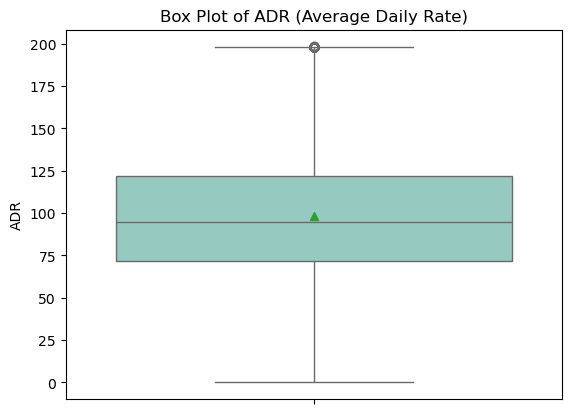

In [110]:
# Box plot for the 'adr' column
sns.boxplot(df['adr'] , palette='Set3', showmeans=True)

# Add a title and labels
plt.title('Box Plot of ADR (Average Daily Rate)')
plt.ylabel('ADR')

# Show the plot
plt.show()


<h2 style= 'color:brown' align = 'center'><u> Pie Chart for Cancellation data</u></h2>

## Uni-Variant analysis
### (pie-chart)

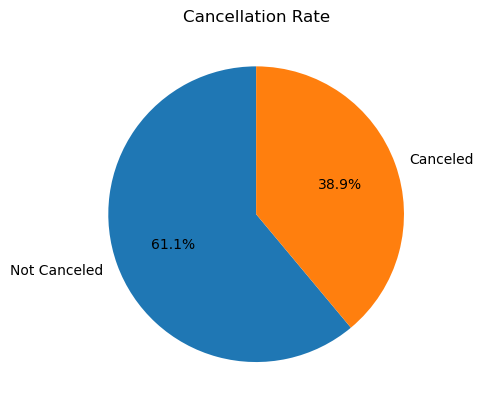

In [120]:
cancellation_counts = df['is_canceled'].value_counts()
labels = ['Not Canceled', 'Canceled']
colors = ['#66b3ff', '#ff9999']
plt.pie(cancellation_counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Cancellation Rate')
plt.show()
#In the graph below, we observe that the cancellation percentage for both city and resort hotels is relatively low.

In [ ]:
#df.describe()

<h2 style= 'color:brown' align = 'center'><u> Count plot for Cancellation data</u></h2>

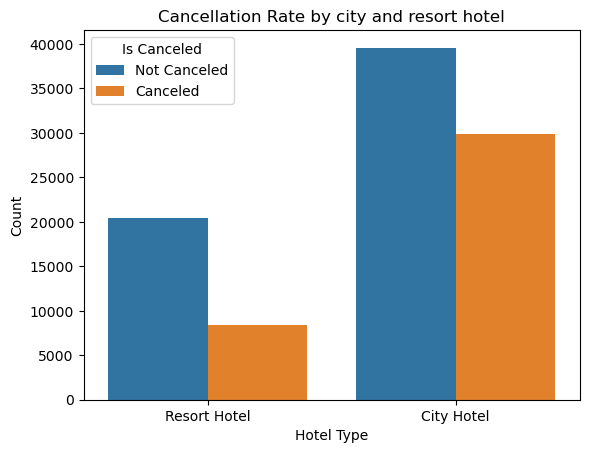

In [112]:
# Creating a count plot for cancellation of resort and city hotel 
sns.countplot(data=df, x='hotel', hue='is_canceled')
plt.title('Cancellation Rate by city and resort hotel')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

# According to the count plot, we observe the specific count of cancellations for each hotel type.
# The data indicates that city hotels perform better than resort hotels in terms of having fewer cancellations.

<h2 style= 'color:brown' align = 'center'><u> bar plot for arrival_date_year </u></h2>


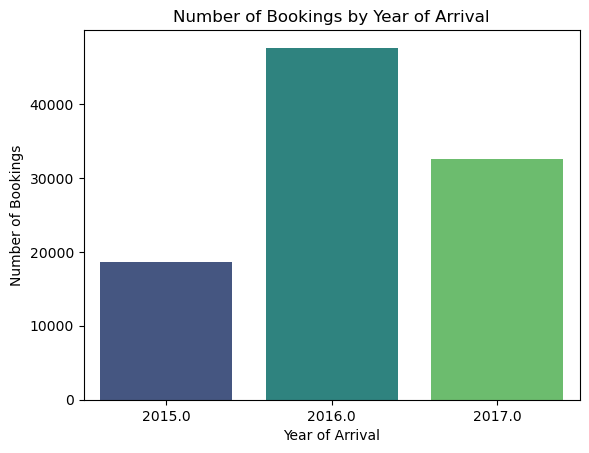

In [94]:
# Counting & sorting the bookings for each year
yearly_counts = df['arrival_date_year'].value_counts().sort_index()
# barPlot for Bookings by Year of Arrival 
sns.barplot(x=yearly_counts.index, y=yearly_counts.values, palette='viridis')
plt.xlabel('Year of Arrival')
plt.ylabel('Number of Bookings')
plt.title('Number of Bookings by Year of Arrival')
plt.show()
# This bar plot shows that 2016 experienced a higher number of bookings compared to 2015 and 2017.

<h2 style= 'color:brown' align = 'center'><u> bar plot for arrival_date_month </u></h2>


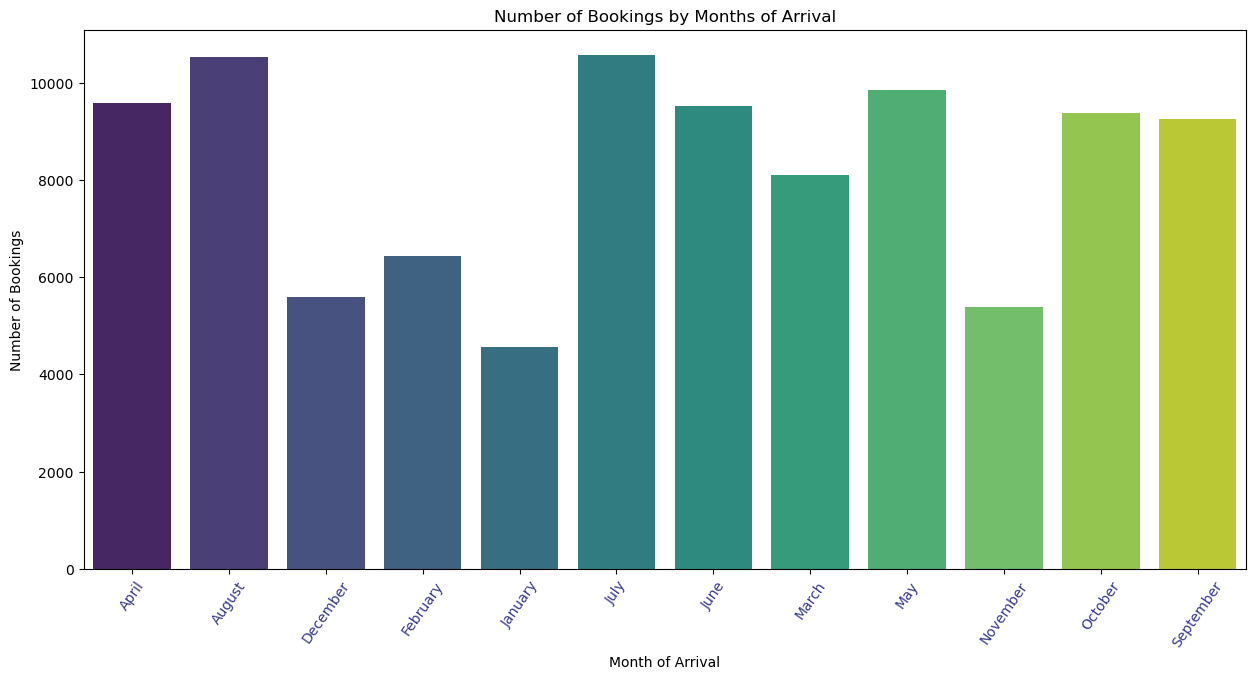

In [96]:
fig = plt.figure(figsize = (15,7)) 
monthly_counts = df['arrival_date_month'].value_counts().sort_index()
# barPlot for Bookings by Year of Arrival 
sns.barplot(x= monthly_counts.index, y= monthly_counts.values, palette='viridis')
plt.xlabel('Month of Arrival')
plt.ylabel('Number of Bookings')
plt.title('Number of Bookings by Months of Arrival')
plt.xticks( rotation=55, fontsize=10 , color = '#343789')
plt.show()
# This bar plot indicates that August has the highest number of bookings compared to other months, while January has the lowest.

<h2 style= 'color:brown' align = 'center'><u> Bar plot for arrival_date_week_number	 </u></h2>


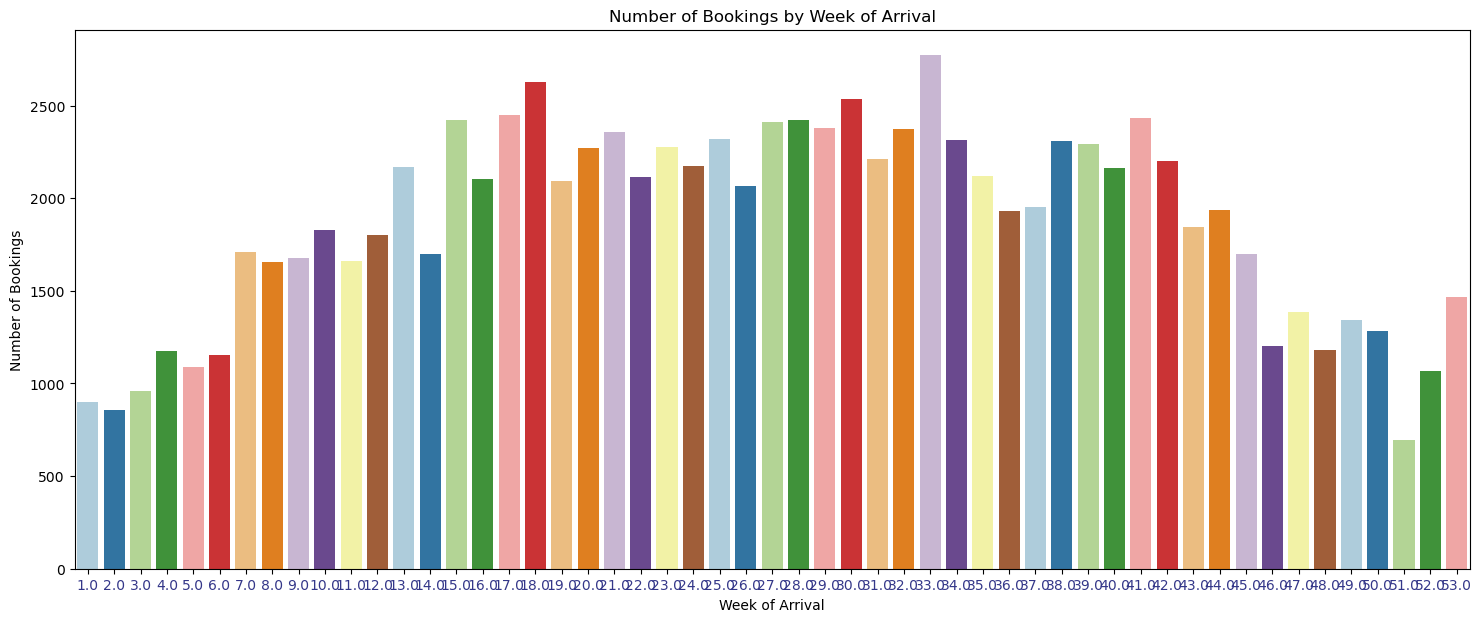

In [59]:
fig = plt.figure(figsize = (18,7)) 
week_counts = df['arrival_date_week_number'].value_counts().sort_index()
# barPlot for Bookings by Year of Arrival 
sns.barplot(x= week_counts.index, y= week_counts.values, palette='Paired')
plt.xlabel('Week of Arrival')
plt.ylabel('Number of Bookings')
plt.title('Number of Bookings by Week of Arrival')
plt.xticks( rotation=00, fontsize=10 , color = '#343789')
plt.show()
#Here’s a rephrased version of your observation:  
#In the graph below, we observe that week 33 has the highest number of bookings, while week 51 has the lowest number of bookings.

<h2 style= 'color:red' align = "center"><u>Arrival_date_day_of_month</u></h2>

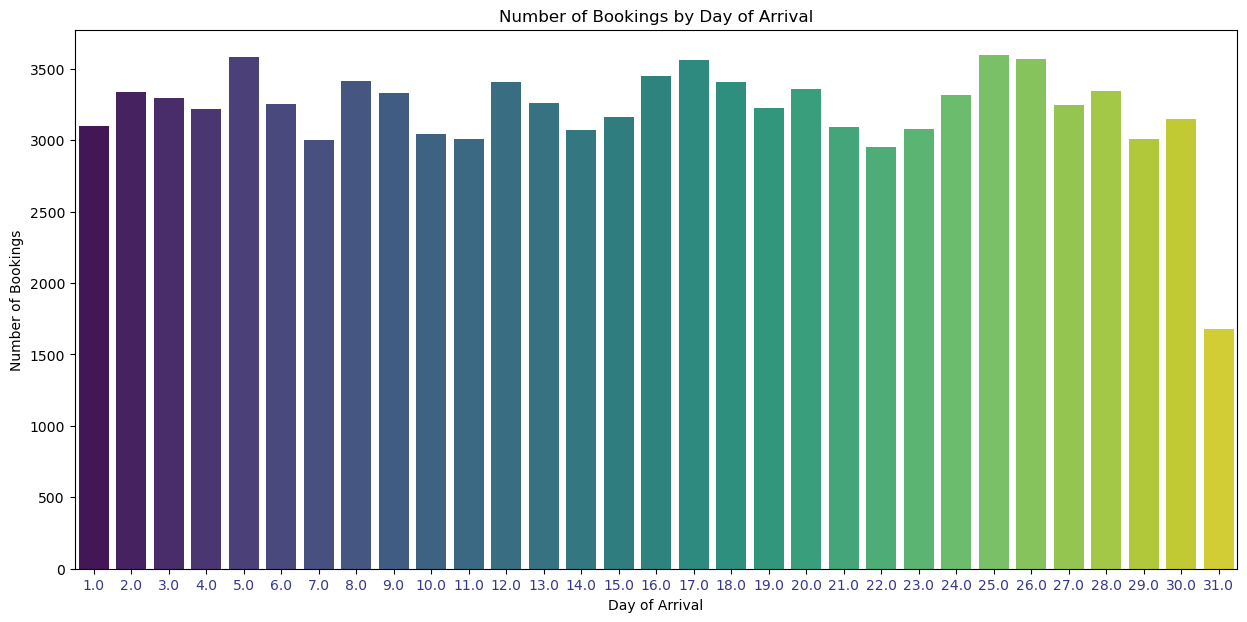

In [62]:
fig = plt.figure(figsize = (15,7)) 
day_counts = df['arrival_date_day_of_month'].value_counts().sort_index()
# barPlot for Bookings by Year of Arrival 
sns.barplot(x= day_counts.index, y= day_counts.values, palette='viridis')
plt.xlabel('Day of Arrival')
plt.ylabel('Number of Bookings')
plt.title('Number of Bookings by Day of Arrival')
plt.xticks( rotation=00, fontsize=10 , color = '#343789')
plt.show()
#In the graph below, we observe that the highest number of bookings occurred on days 5, 17, 25, and 26, while day 31 has the lowest number of bookings.

<h2 style= 'color:brown' align = 'center'><u> Countplot for stays_in_weekend_nights </u></h2>


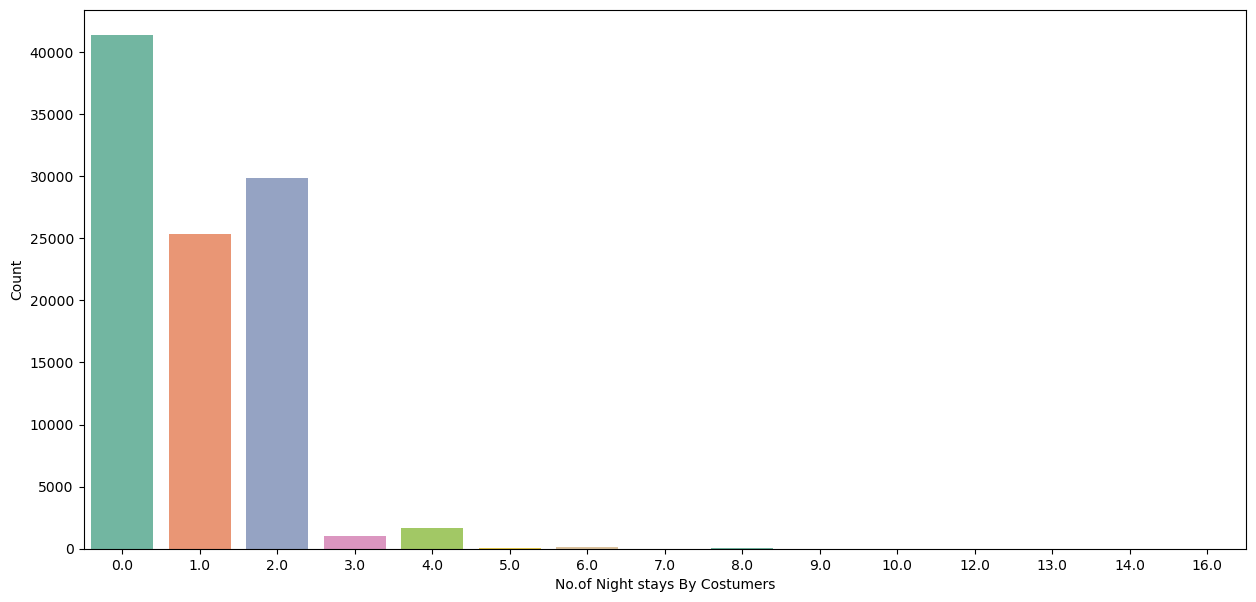

In [65]:
fig = plt.figure(figsize = (15,7)) 
sns.countplot(data=df, x='stays_in_weekend_nights', palette='Set2')
plt.xlabel("No.of Night stays By Costumers")
plt.ylabel("Count")
plt.show()
# in this count plot has less bookings for night stays on weekends

<h2 style= 'color:brown' align = 'center'><u> Countplot for stays_in_week_nights </u></h2>


<function matplotlib.pyplot.show(close=None, block=None)>

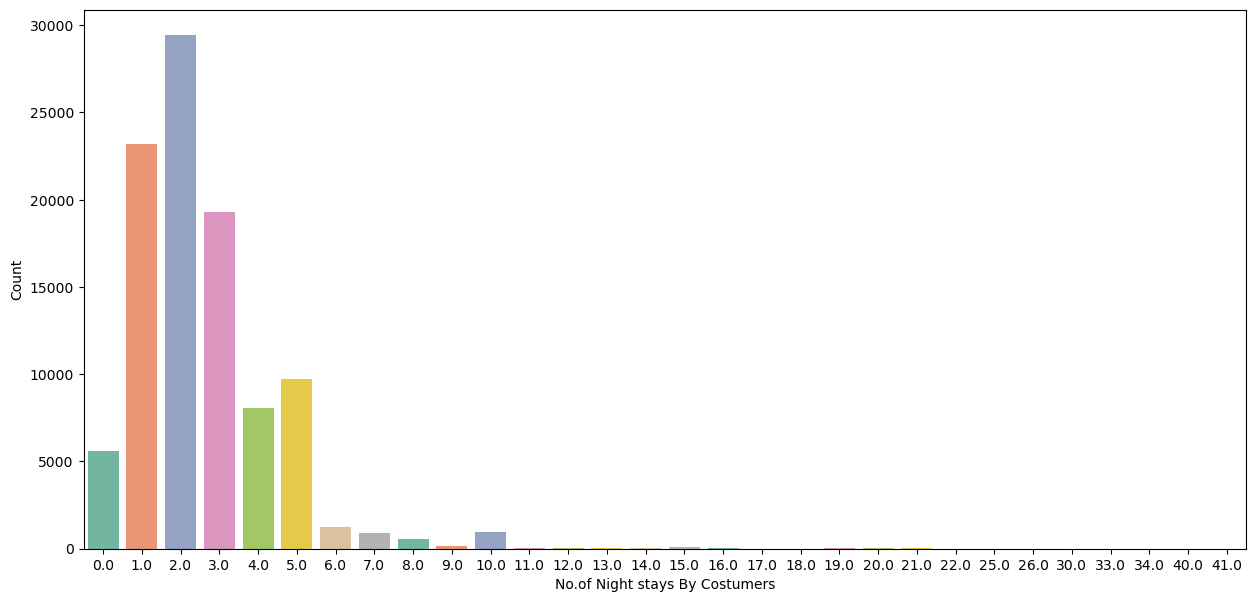

In [68]:
fig = plt.figure(figsize = (15,7)) 
sns.countplot(data=df, x='stays_in_week_nights', palette='Set2')
plt.xlabel("No.of Night stays By Costumers")
plt.ylabel("Count")
plt.show
# By this countplot we can analyze the data about how many night stays are booked
# There are more booking for "2 days" on week nights

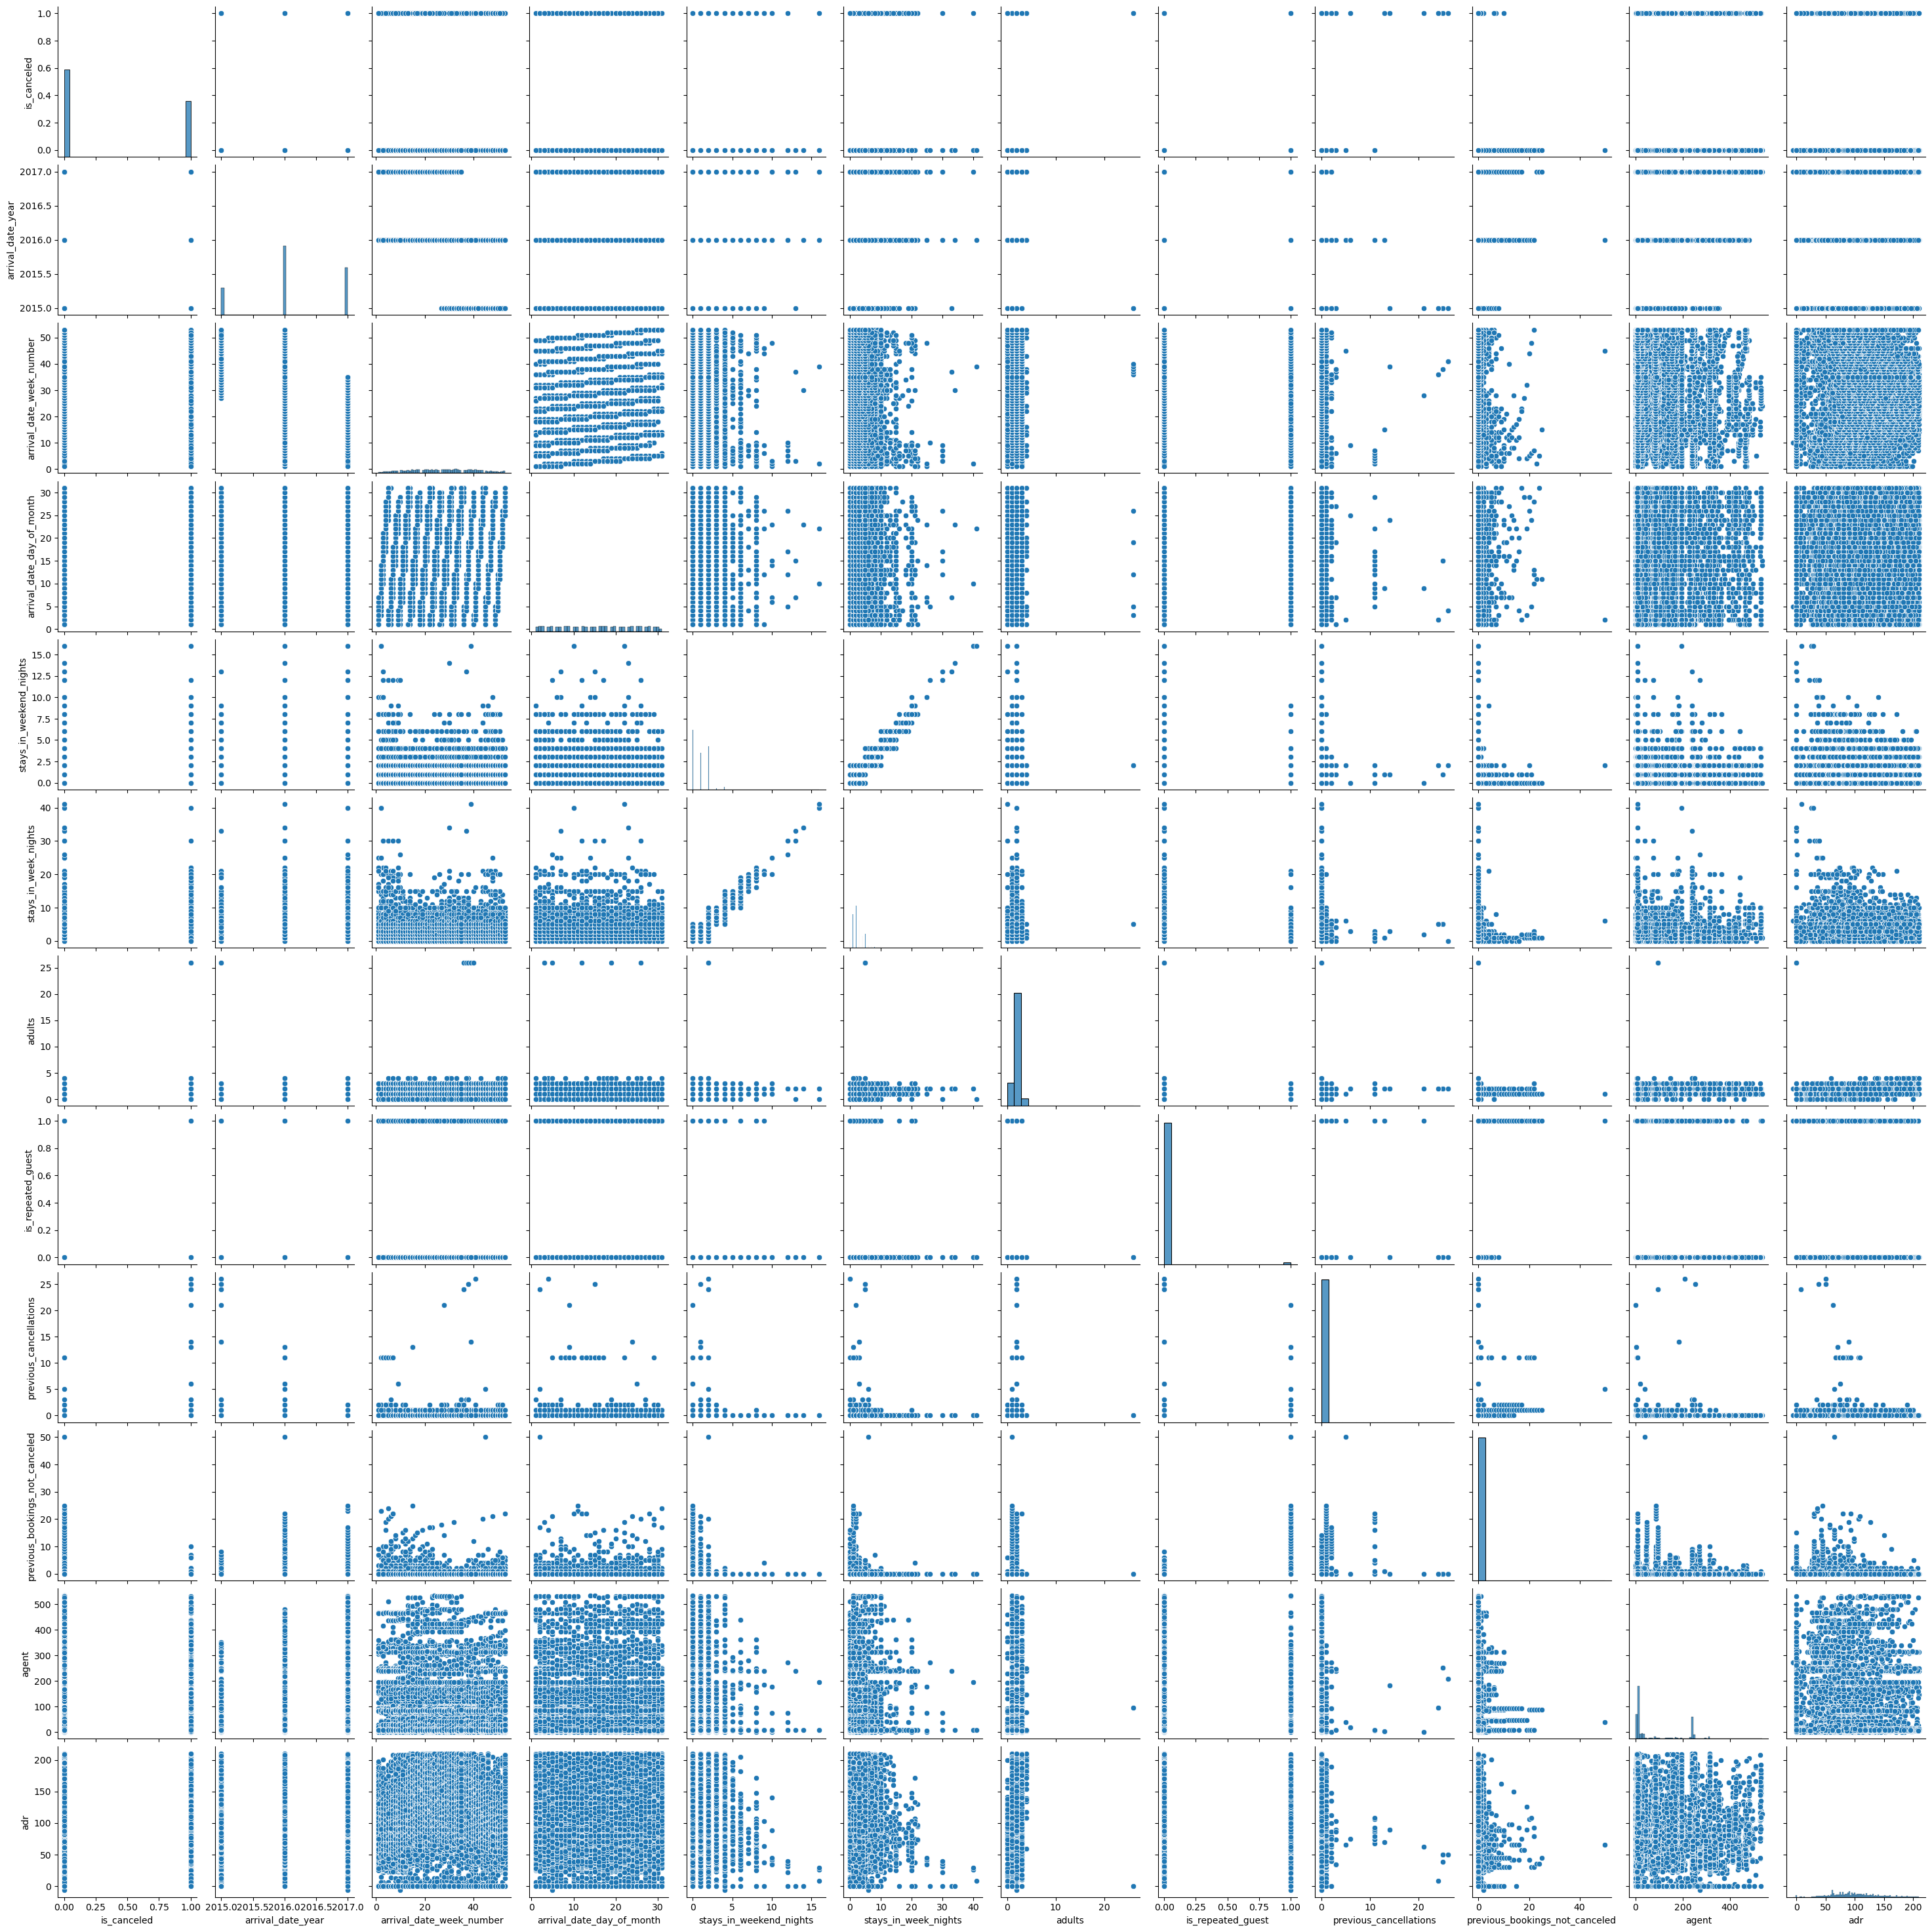

In [71]:
sns.pairplot(df)
plt.show()
#we found insights and identify relationships, detect outliers,across hotel types and customer behaviors.


